# PGA Tour Putting Data

The [Shotlink System](https://shotlink.com/about/history) provides detailed shot-by-shot location data for PGA Tour events, and these data led to many groundbreaking advances in golf analytics. The [strokes gained](http://www.columbia.edu/~mnb2/broadie/Assets/broadie_wscg_v_200804.pdf) metric, a measure of how a golfer's shots compare to an expectation given ball location and other information, headlines these advances.

This notebook aims to focus on a subset of strokes gained: putting. [Broadie](https://www0.gsb.columbia.edu/mygsb/faculty/research/pubfiles/4996/assessing_golfer_performance.full.pdf) constructs two models, a one-putt and three-putt model. The one-putt model follows a statistical approach motivated through the physics of putting and models both the probability that a putt is on target and hit with sufficient pace to result in a holeout. The three-putt model is a logistic regression that is solely the function of distance from the hole. [Fearing et al.](http://dspace.mit.edu/bitstream/handle/1721.1/107940/Fearing%20Acimovic%20Graves%202011.pdf?sequence=1&isAllowed=y) focus exclusively on putting and approach the problem through a different lens, modeling separately the probability of making a putt and the distance remaining to the hole conditioned on a miss. These are modeled via logistic and gamma regression, respectively.

This notebook uses the foundation established by the work above as a starting point to explore PGA Tour Shotlink data and construct a putting probability model.


In [1]:
%pip install pygam

import numpy as np
import pandas as pd
import math
import pickle
import matplotlib.pyplot as plt
import scipy
import scipy.stats as st
import xarray as xr

import statsmodels.api as sm
from statsmodels.gam.api import GLMGam, BSplines
from scipy.special import expit

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss

from pygam import LogisticGAM, s, f, te

import plotly.express as px
import plotly.graph_objects as go
import plotly.offline as pyo

In [2]:
putt_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/putts.csv")
putt_df = putt_df[putt_df["distance"]!="--"]

/tmp/ipykernel_4937/2190842510.py:1: DtypeWarning:

Columns (15,75,76) have mixed types. Specify dtype option on import or set low_memory=False.



In [3]:
putt_df[["distance", "distance_round", "shotNumber", "left", "from_x", "from_y", "from_z", "x", "y", "z",
         "putt", "from", "to", "cup"]]

,distance,distance_round,shotNumber,left,from_x,from_y,from_z,x,y,z,putt,from,to,cup
0,10 in.,1.0,5.0,0 in.,10353.2,11391.33,653.379,10353.6,11392.20,653.372,True,OGR,NaN,True
1,2 ft 9 in.,3.0,5.0,0 in.,12273.2,8113.52,651.552,12275.5,8111.69,651.597,True,OGR,NaN,True
2,9 in.,1.0,5.0,0 in.,11342.1,8388.23,646.571,11341.3,8388.47,646.524,True,OGR,NaN,True
3,23 in.,2.0,4.0,0 in.,12243.1,8127.85,651.018,12241.2,8128.79,651.000,True,OGR,NaN,True
4,7 ft 11 in.,8.0,4.0,0 in.,10044.5,9225.12,644.728,10052.6,9224.65,644.604,True,OGR,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
944514,22 ft 0 in.,22.0,2.0,4 in.,12903.8,11989.44,672.398,12889.1,12005.81,672.240,True,OGR,OGR,False
944515,32 ft 8 in.,33.0,3.0,16 in.,13361.5,10596.28,613.015,13372.4,10565.47,612.562,True,OGR,OGR,False
944516,36 ft 0 in.,36.0,4.0,12 in.,13154.0,11231.95,631.006,13170.5,11263.91,631.582,True,OGR,OGR,False
944517,26 ft 9 in.,27.0,4.0,4 in.,13162.0,11238.69,631.176,13172.0,11263.51,631.559,True,OGR,OGR,False


These data have been filtered and aggregated from the shot-by-shot data. Data cleaning included

- Removing shots with missing or zero distance from the hole
- Ensuring each event-year-golfer-round-hole has a tee shot and hole out
- Requiring each putt to take place on the green (off-the-green putts would be handled upstream via approach expected strokes)

Let's take a look at the distribution of putts remaining (after the putt in question)

In [4]:
max_putt_df = pd.DataFrame(putt_df.groupby(["player_id", "event_id", "year",
                                            "round_num", "course", "hole"])["shotNumber"].max()).reset_index()
max_putt_df.columns = ["player_id", "event_id", "year", "round_num", "course", "hole", "total_putts"]
putt_df = putt_df.merge(max_putt_df, on=["player_id", "event_id", "year", "round_num", "course", "hole"])
putt_df["putts_remaining"] = putt_df["total_putts"] - putt_df["shotNumber"]

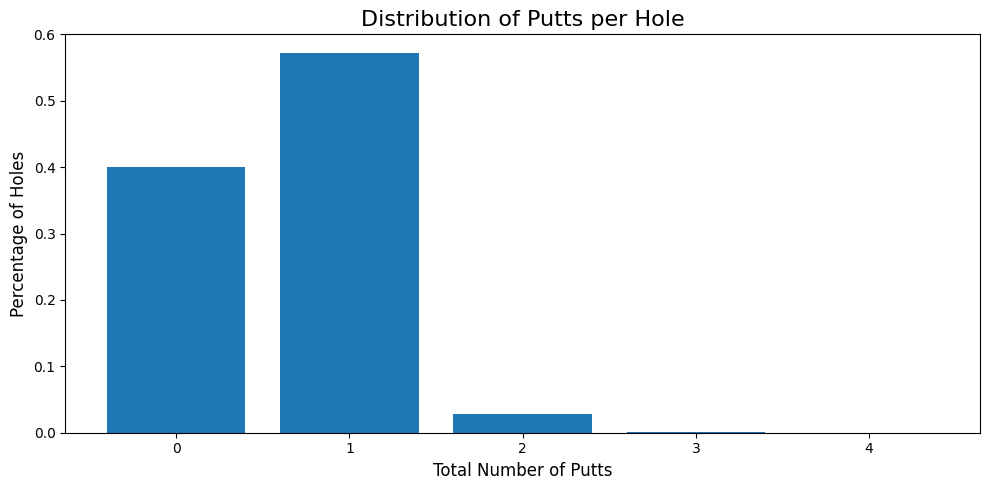

In [5]:
total_putt_df = pd.DataFrame(putt_df.groupby(["player_id", "event_id", "year",
                                              "round_num", "course", "hole"])["putts_remaining"].max()).reset_index()
total_putt_df["putts_remaining"] = [int(x) for x in total_putt_df["putts_remaining"]]
count_df = total_putt_df.groupby("putts_remaining")["hole"].count().reset_index()
count_df.columns = ["putts_remaining", "count"]
count_df["fraction"] = count_df["count"] / count_df["count"].sum()

# Visualize
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)

ax.bar(count_df["putts_remaining"], count_df["fraction"])
ax.set_xlabel("Total Number of Putts", fontsize=12)
ax.set_ylabel("Percentage of Holes", fontsize=12)
ax.set_title("Distribution of Putts per Hole", fontsize=16)
plt.tight_layout()
plt.show()

Nearly 60% of putts require one additional putt, while 40% of putts hole out. The remainder 3+ putts are quite rare on the PGA Tour.

## Data Processing
You'll note that the `distance` field is represented by strings with units of `ft` and or `in.`, so the following converts the field to `distance_float` in units of feet.

In [6]:
putt_df["distance_float"] = [
    int(x.split("ft")[0].strip(' ')) + float(x.split("ft ")[1].strip(' in.'))/12 if "ft" in x
    else float(x.strip(' in.'))/12 for x in putt_df["distance"]
]

hole_df = putt_df[putt_df["cup"]][["event_id", "year",
                                            "round_num", "course", "hole", "x", "y", "z"]].drop_duplicates()
hole_df.columns = ["event_id", "year", "round_num", "course", "hole", "hole_x", "hole_y", "hole_z"]
putt_df = putt_df.merge(hole_df, on=["event_id", "year", "round_num", "course", "hole"])

putt_df["relative_z"] = putt_df["hole_z"] - putt_df["from_z"]
putt_df = putt_df[(putt_df["distance_float"]>0) & (putt_df["distance_float"]<75)]

In [7]:
putt_df[["distance", "distance_float", "shotNumber", "left", "from_x", "from_y", "from_z", "x", "y", "z",
         "putt", "from", "to", "cup"]]

,distance,distance_float,shotNumber,left,from_x,from_y,from_z,x,y,z,putt,from,to,cup
0,10 in.,0.833333,5.0,0 in.,10353.2,11391.33,653.379,10353.6,11392.20,653.372,True,OGR,NaN,True
1,2 ft 9 in.,2.750000,5.0,0 in.,12273.2,8113.52,651.552,12275.5,8111.69,651.597,True,OGR,NaN,True
2,9 in.,0.750000,5.0,0 in.,11342.1,8388.23,646.571,11341.3,8388.47,646.524,True,OGR,NaN,True
3,23 in.,1.916667,4.0,0 in.,12243.1,8127.85,651.018,12241.2,8128.79,651.000,True,OGR,NaN,True
4,7 ft 11 in.,7.916667,4.0,0 in.,10044.5,9225.12,644.728,10052.6,9224.65,644.604,True,OGR,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926284,22 ft 0 in.,22.000000,2.0,4 in.,12903.8,11989.44,672.398,12889.1,12005.81,672.240,True,OGR,OGR,False
926285,32 ft 8 in.,32.666667,3.0,16 in.,13361.5,10596.28,613.015,13372.4,10565.47,612.562,True,OGR,OGR,False
926286,36 ft 0 in.,36.000000,4.0,12 in.,13154.0,11231.95,631.006,13170.5,11263.91,631.582,True,OGR,OGR,False
926287,26 ft 9 in.,26.750000,4.0,4 in.,13162.0,11238.69,631.176,13172.0,11263.51,631.559,True,OGR,OGR,False


## One-Putt Probability

We'll take Broadie's lead and fit separate models for one- and three-putt outcomes given the distribution in the present above. Given the nonlinearity of the relationship between holing out and distance, the following leverages splines for distance from the hole.

In [8]:
# Features and target
features = ["distance_float"]
putt_df["cup"] = [1 if x else 0 for x in putt_df["cup"]]
target = ["cup"]

# Split dataset
train_df, test_df = train_test_split(putt_df, test_size=0.2, random_state=42)

# Distance spline
x_spline = train_df[features]
bs = BSplines(x_spline, df=[15], degree=[3])

gam_bs = GLMGam.from_formula('cup ~ distance_float - 1', data=train_df,
                              smoother=bs,
                              family=sm.families.Binomial())

## Three-Putt Model

This follows the same approach, but swaps out the target variable for three-putt outcomes.

In [9]:
features = ["distance_float"]
target = ["three_putt"]
train_df["three_putt"] = [1 if x >= 2 else 0 for x in train_df["putts_remaining"]]
test_df["three_putt"] = [1 if x >= 2 else 0 for x in test_df["putts_remaining"]]


gam_bs_t = GLMGam.from_formula('three_putt ~ distance_float - 1', data=train_df,
                              smoother=bs,
                              family=sm.families.Binomial())

In [10]:
# Fit the models and examine the summaries
res_bs = gam_bs.fit()
res_bs_t = gam_bs_t.fit()

In [11]:
print(res_bs.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    cup   No. Observations:               732381
Model:                         GLMGam   Df Residuals:                732366.00
Model Family:                Binomial   Df Model:                        14.00
Link Function:                  Logit   Scale:                          1.0000
Method:                         PIRLS   Log-Likelihood:            -1.7954e+05
Date:                Thu, 24 Sep 2026   Deviance:                   3.5908e+05
Time:                        19:36:43   Pearson chi2:                 7.36e+05
No. Iterations:                    12   Pseudo R-squ. (CS):             0.5704
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
distance_float        60.7512      3

In [12]:
print(res_bs_t.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             three_putt   No. Observations:               732381
Model:                         GLMGam   Df Residuals:                732366.00
Model Family:                Binomial   Df Model:                        14.00
Link Function:                  Logit   Scale:                          1.0000
Method:                         PIRLS   Log-Likelihood:                -44595.
Date:                Thu, 24 Sep 2026   Deviance:                       89190.
Time:                        19:36:43   Pearson chi2:                 7.34e+05
No. Iterations:                    14   Pseudo R-squ. (CS):            0.04938
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
distance_float       -99.9313     14

In [13]:
# Store model objects
save_dict = {
    "splines": bs,
    "coef_p": res_bs.params,
    "coef_t": res_bs_t.params
}

## Validation

With our models constructed, let's examine and validate their performance. With just one feature, the following constructs the linear predictor from the coefficients and splines directly, then uses `expit` to get the output on the probability scale.

In [14]:
# Training predictions
preds = save_dict["coef_p"]["distance_float"]*x_spline["distance_float"] + \
    np.dot(bs.transform(np.array(x_spline["distance_float"])), np.array(save_dict["coef_p"].iloc[1:]))
preds_t = save_dict["coef_t"]["distance_float"]*x_spline["distance_float"] + \
    np.dot(bs.transform(np.array(x_spline["distance_float"])), np.array(save_dict["coef_t"].iloc[1:]))

train_df["preds"] = expit(preds)
train_df["preds_t"] = expit(preds_t)

# Test predictions
x_spline_test = test_df[features]

preds = save_dict["coef_p"]["distance_float"]*x_spline_test["distance_float"] + \
    np.dot(bs.transform(np.array(x_spline_test["distance_float"])), np.array(save_dict["coef_p"].iloc[1:]))
preds_t = save_dict["coef_t"]["distance_float"]*x_spline_test["distance_float"] + \
    np.dot(bs.transform(np.array(x_spline_test["distance_float"])), np.array(save_dict["coef_t"].iloc[1:]))

test_df["preds"] = expit(preds)
test_df["preds_t"] = expit(preds_t)

In [15]:
# Construct visualization
group_df = pd.DataFrame(test_df.groupby("distance_round")[["cup", "preds"]].mean()).reset_index()
group_df["target"] = [round(x, 3) for x in group_df["cup"]]
group_df["predictions"] = [round(x, 3) for x in group_df["preds"]]

fig = go.Figure()

# Empirical data
fig.add_trace(go.Scatter(x=group_df["distance_round"], y=group_df["target"],
                    mode='markers', name='Observed',
                        ))

# Predicted curve
fig.add_trace(go.Scatter(x=group_df["distance_round"], y=group_df["predictions"],
                    mode='lines', name='Predicted',
                        ))

fig.update_layout(title="Observed Rate and Predicted Probability of Made Putts By Distance",
                  xaxis_title="Putt Distance (ft)",
                  yaxis_title="Putt Success Probability",
                  font=dict(size=14))
pyo.iplot(fig, filename = 'fig2')

In [16]:
# Construct visualization
group_df = pd.DataFrame(test_df.groupby("distance_round")[["cup", "preds_t"]].mean()).reset_index()
group_df["target"] = [round(x, 3) for x in group_df["preds_t"]]
group_df["predictions"] = [round(x, 3) for x in group_df["preds_t"]]

fig = go.Figure()

# Empirical data
fig.add_trace(go.Scatter(x=group_df["distance_round"], y=group_df["target"],
                    mode='markers', name='Observed',
                        ))

# Predicted curve
fig.add_trace(go.Scatter(x=group_df["distance_round"], y=group_df["predictions"],
                    mode='lines', name='Predicted',
                        ))

fig.update_layout(title="Observed Rate and Predicted Probability of Three-Putts By Distance",
                  xaxis_title="Putt Distance (ft)",
                  yaxis_title="Three-Putt Probability",
                  font=dict(size=14))
pyo.iplot(fig, filename = 'fig2')

The above figures show that the one-putt and three-putt models are generally well-calibrated, so let's take a quick peek at the log loss for each model. With training and test set performance tracking each other, the models seem to be capturing the relationship between putting success and distance well.

In [17]:
print("One-putt Probability")
print("Training Set Log Loss: " + str(round(log_loss(train_df["cup"],
                                                           train_df["preds"]), 3)))
print("Test Set Log Loss: " + str(round(log_loss(test_df["cup"],
                                                       test_df["preds"]), 3)))
print("********************")
print("Three-putt Probability")
print("Training Set Log Loss: " + str(round(log_loss(train_df["three_putt"],
                                                           train_df["preds_t"]), 3)))
print("Test Set Log Loss: " + str(round(log_loss(test_df["three_putt"],
                                                       test_df["preds_t"]), 3)))

One-putt Probability
Training Set Log Loss: 0.245
Test Set Log Loss: 0.245
********************
Three-putt Probability
Training Set Log Loss: 0.061
Test Set Log Loss: 0.06


In [34]:
with open('/content/drive/MyDrive/Golf/putt_model.pkl', 'wb') as handle:
    pickle.dump(save_dict, handle)